In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


# Figures definitives

## 1. Caracterització

In [ ]:
fixed_source = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :active => Bool,

        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,

        :sigma => Float64, #Gaussian width. 
        :R_source => Float64
    ),

    # medium = Dict(
    #     :mm => Float64
    # ),

    agentODE = quote  

        r = sqrt((x)^2 + (y)^2)
        ll = sqrt(DMedium / delta)

        # evitar singularidad en r=0
        r_eff = max(r, 1e-3)

        mm = 1.0 * besselk(0, r_eff / ll)

        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) 

        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = vx 
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote

        v_run = v
        v_tumble = 0.25 

        speed = active ? v_run : v_tumble

        Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble

        if active 
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)  
                
        end


        if active 
            λrt = ωFrec*exp(-G) 

            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
            if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                active = false
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
            else     #Si rate baixa 
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
            end

        else
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            else
                active = false
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            end
        end
    end,
    
    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=10)
)

In [ ]:
# ns = [0.0125, 0.025, 0.05, 0.1, 0.2]
steps = 100000
vel = [10.0, 20.0, 50.0, 60.0, 75.0, 80.0, 100.0]
end
noss...
# for n in ns
    for (idx, v) in enumerate(vel)
        println("Running n=$v")

        com = Community(
            fixed_source,
            N=500,
            dt=0.01,
            simBox = [-100.0 100.0; -100.0 100.0],
            NMedium = [100, 100]
        )   

        m = 1/100
        g = 1/10000
        d = 1

        com.Dr_run = 0.062

        com.v = v 

        com.ωFrec = 1.3
        com.Ki = 0.0182
        com.Ka = 3.0
        com.Nrec = 6.0
        com.ε0   = 6.0
        com.ε1   = -1.0
        com.ε2   = 80
        com.ε3   = 80

        com.τm = 1  

        com.α   = 6.0

        com.K = 2.0 

        com.Ky = 100.0
        com.Kz = 10.0
        com.Z = 5.0
        com.Yy = 0.1

        com.m = 1.        
        com.d = 1.        
        com.l = 3;

        # Dc = 10 
        # delta = 0.01

        # d = delta/((v/10)^2)

        #Canviar lambda

        com.DMedium = 10
        com.delta = 0.0001

        com.x = 2.5*sqrt(com.DMedium/com.delta)
        com.y = 2.5*sqrt(com.DMedium/com.delta)
        com.theta = rand(Uniform(0,2π),com.N)

        com.methyl .= 0.0
        com.Yp .= com.K


        loadToPlatform!(com, preallocateAgents=1000)
        
        outfile = @sprintf("fsb_v%s_l316_D.jld2", v)  ###CANVIARRR NOOM

        jldopen(outfile, "w") do file

            for step in 1:steps
                CellBasedModels.step!(com)

                stepname = @sprintf("step_%06d", step)
                g = JLD2.Group(file, stepname)

                # Agent-level arrays (length = N)
                g["x"] = copy(com.x)
                g["y"] = copy(com.y)
                g["theta"] = copy(com.theta)

    
            end
        end
    end
# end

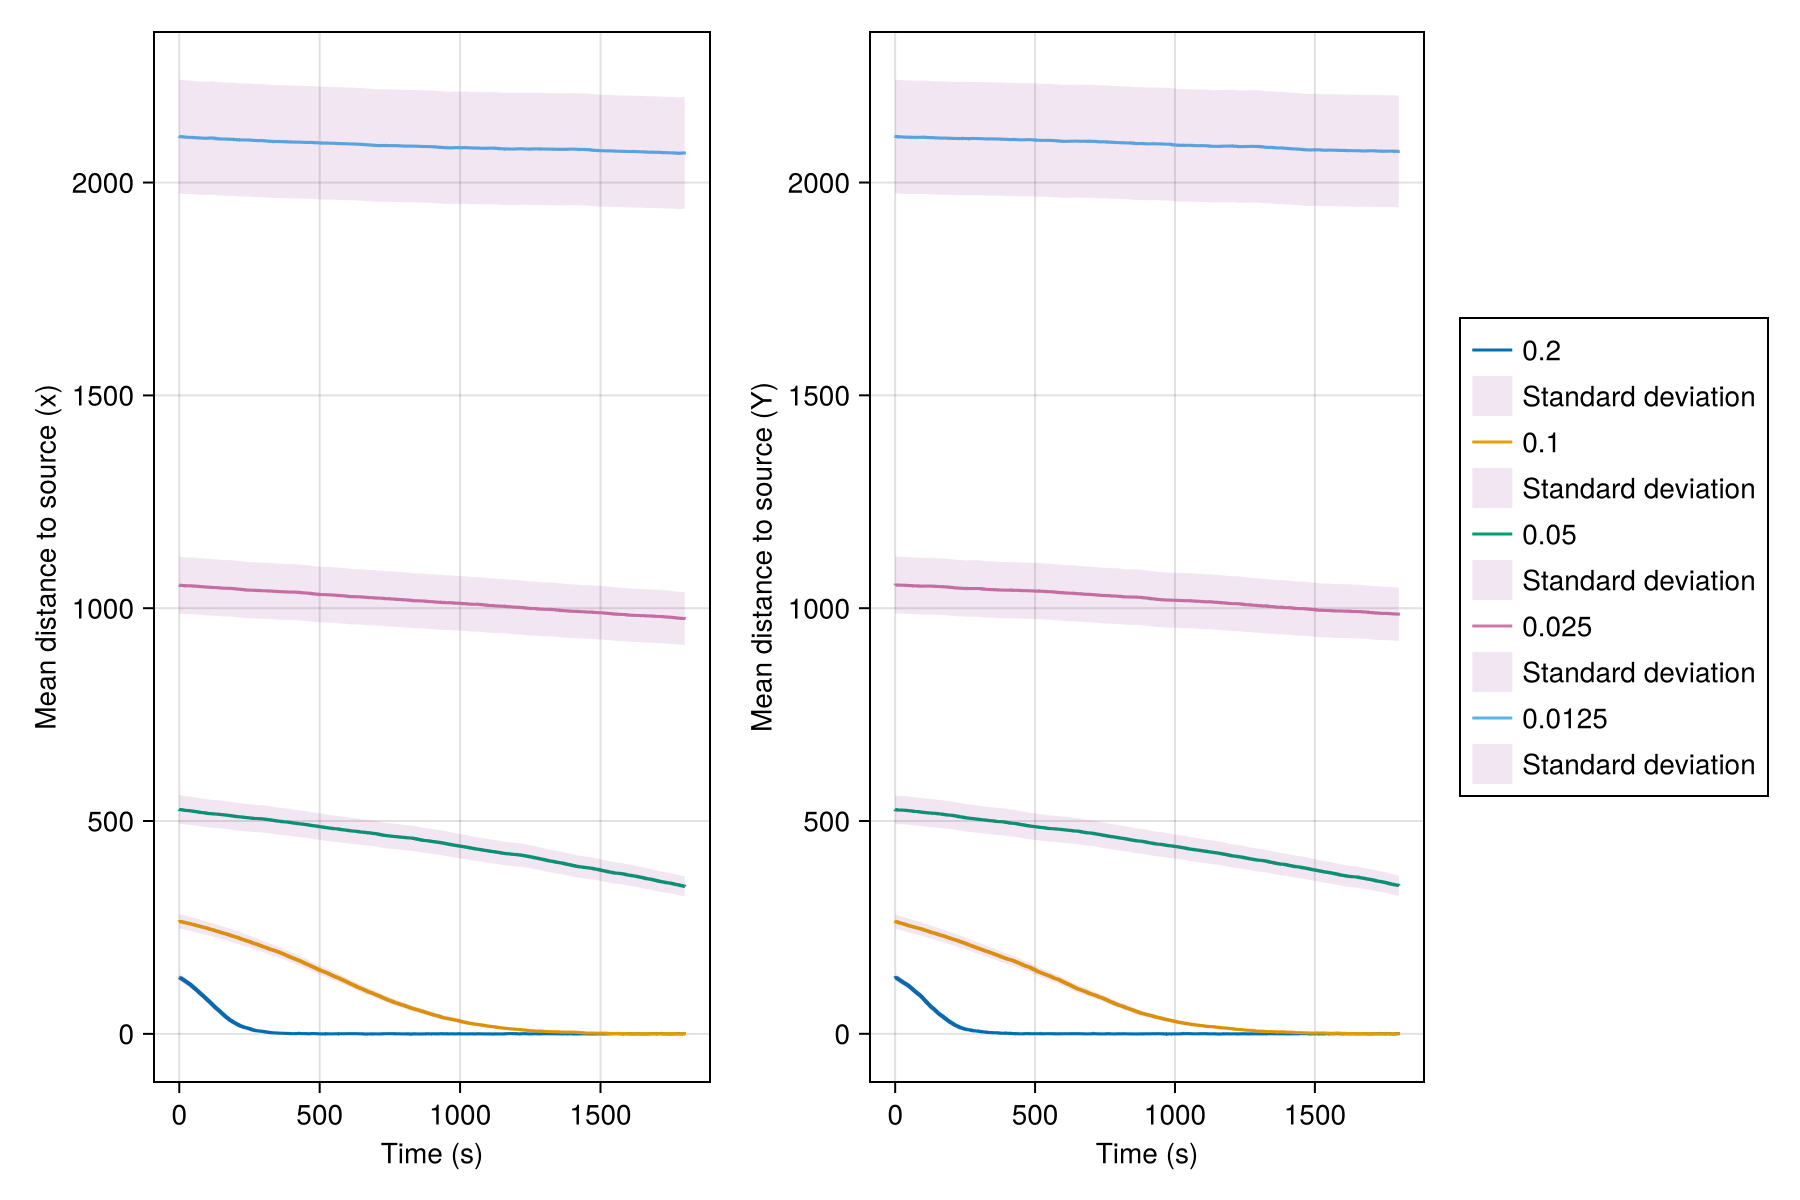

CairoMakie.Screen{IMAGE}


In [5]:
using CairoMakie
fig3 = Figure(size=(900, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Mean distance to source (x)")
ax2 = Axis(fig3[1,2], xlabel="Time (s)", ylabel="Mean distance to source (Y)")
steps = 180000

v = [10, 20, 50, 100]
ls = [0.2, 0.1, 0.05, 0.025, 0.0125]

for i in 1:length(ls)

    mean_dist_x = Float64[] 
    std_dist_x = Float64[]
    mean_dist_y = Float64[] 
    std_dist_y = Float64[]
    jldopen("fsb_v10.0_l$(ls[i])_k.jld2", "r") do file 

        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            xs = 0
            ys = 0

            other_x = g["x"]

            other_y = g["y"]

            dists_x = other_x .- xs
            dists_y = other_y .- ys
            norm_x = dists_x
            norm_y = dists_y

            push!(mean_dist_x, mean(norm_x))
            push!(std_dist_x, std(norm_x))
            push!(mean_dist_y, mean(norm_y))
            push!(std_dist_y, std(norm_y))

        end

        std_X = std_dist_x ./ sqrt(500)
        std_Y = std_dist_y ./ sqrt(500)

        lines!(ax1, (1:steps)*0.01, mean_dist_x, label = "$(ls[i])")
        band!(ax1, (1:steps)*0.01, mean_dist_x .- std_X, mean_dist_x .+ std_X, color=(:purple, 0.1), label = "Standard deviation")
        
        lines!(ax2, (1:steps)*0.01, mean_dist_y)
        band!(ax2, (1:steps)*0.01, mean_dist_y .- std_Y, mean_dist_y .+ std_Y, color=(:purple, 0.1), label = "Standard deviation") 

    end
end
fig3[1,3] = Legend(fig3, ax1) 

display(fig3)

# Attractant fields l

In [2]:
function meshgrid(x, y)
    X = repeat(x', length(y), 1)
    Y = repeat(y, 1, length(x))
    return X, Y
end

meshgrid (generic function with 1 method)

In [ ]:
xs, ys = 0.0, 0.0


len = Int(100 + 100)

x_grid = range(-100, 100, length=len)
y_grid = range(-100, 100, length=len)

X, Y = meshgrid(x_grid, y_grid)

λ = sqrt(800 / 0.01)
# λ = sqrt(com.DMedium / com.delta)

r = sqrt.((X .- xs).^2 .+ (Y .- ys).^2)

mm_grid = @. 1.0 * besselk(0, r / λ)

# Bacteria lambdas 05, 3, 10

In [55]:
function meshgrid(x, y)
    X = repeat(x', length(y), 1)
    Y = repeat(y, 1, length(x))
    return X, Y
end

meshgrid (generic function with 1 method)

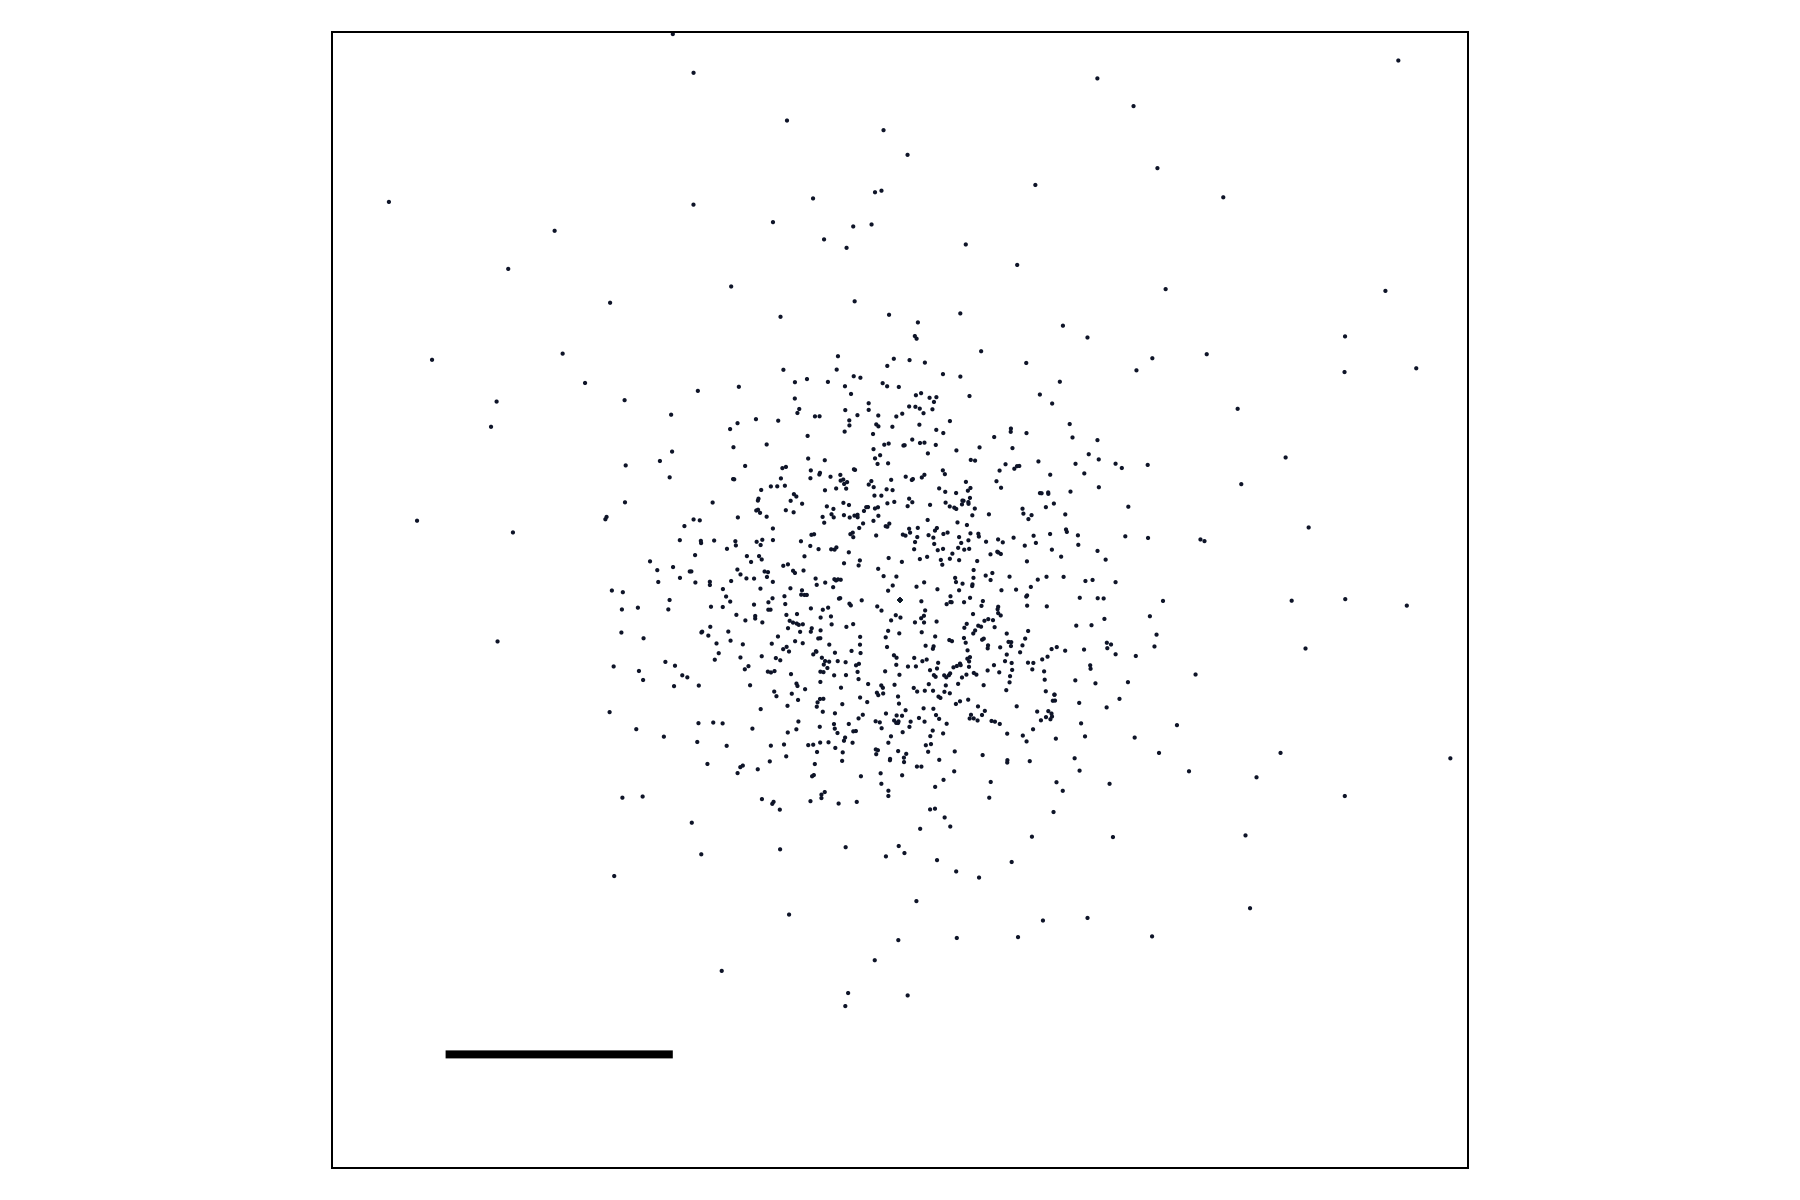

CairoMakie.Screen{IMAGE}


In [105]:
using CairoMakie
fig4 = Figure(size=(900,600))

dark = colorant"#645986"
bac = colorant"#0E1428"
dark2 = colorant"#7D84B2"
light = colorant"#F2EEF9"
white = colorant"#FFFFFF"
cmap = cgrad([white, dark2])

xs, ys = 0.0, 0.0
len = Int(100 + 100)

x_grid = range(-100, 100, length=len)
y_grid = range(-100, 100, length=len)

X, Y = meshgrid(x_grid, y_grid)

λ = sqrt(2/ 0.1)

r = sqrt.((X .- xs).^2 .+ (Y .- ys).^2)

mm_grid = @. 1.0 * besselk(0, r / λ)

jldopen("fsb_simulations/fsb_lambda_v100.0_l0.5.jld2", "r") do file 


        x = Vector{Float64}(undef, 1)
        y = Vector{Float64}(undef, 1)

        ax = Axis(fig4[1, 1], aspect=1)
        xlims!(-500, 500)
        ylims!(-500, 500)

        g = file[@sprintf("step_%06d", 10000)]
    

        # heatmap!(ax, x_grid, y_grid, mm_grid, colormap=cmap)

        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3

        for i in 1:length(x)
            scatter!(ax, x[i], y[i], color=bac, markersize=3)
        end

    hidedecorations!(ax)
    x0 = -400
    y0 = -400
    bar_len = 200
    lines!(ax, [x0, x0 + bar_len], [y0, y0], color = :black, linewidth = 4)

end




display(fig4)

In [106]:
save("Plots/Fixed_source_model/Next/agents_l05_bar.pdf", fig4)

CairoMakie.Screen{PDF}


# V collapse for three lambdas

In [2]:
@load "redo_dfs.jld2" dfs_redo

1-element Vector{Symbol}:
 :dfs_redo

In [3]:
@load "dc_delta.jld2" dc_delta

1-element Vector{Symbol}:
 :dc_delta

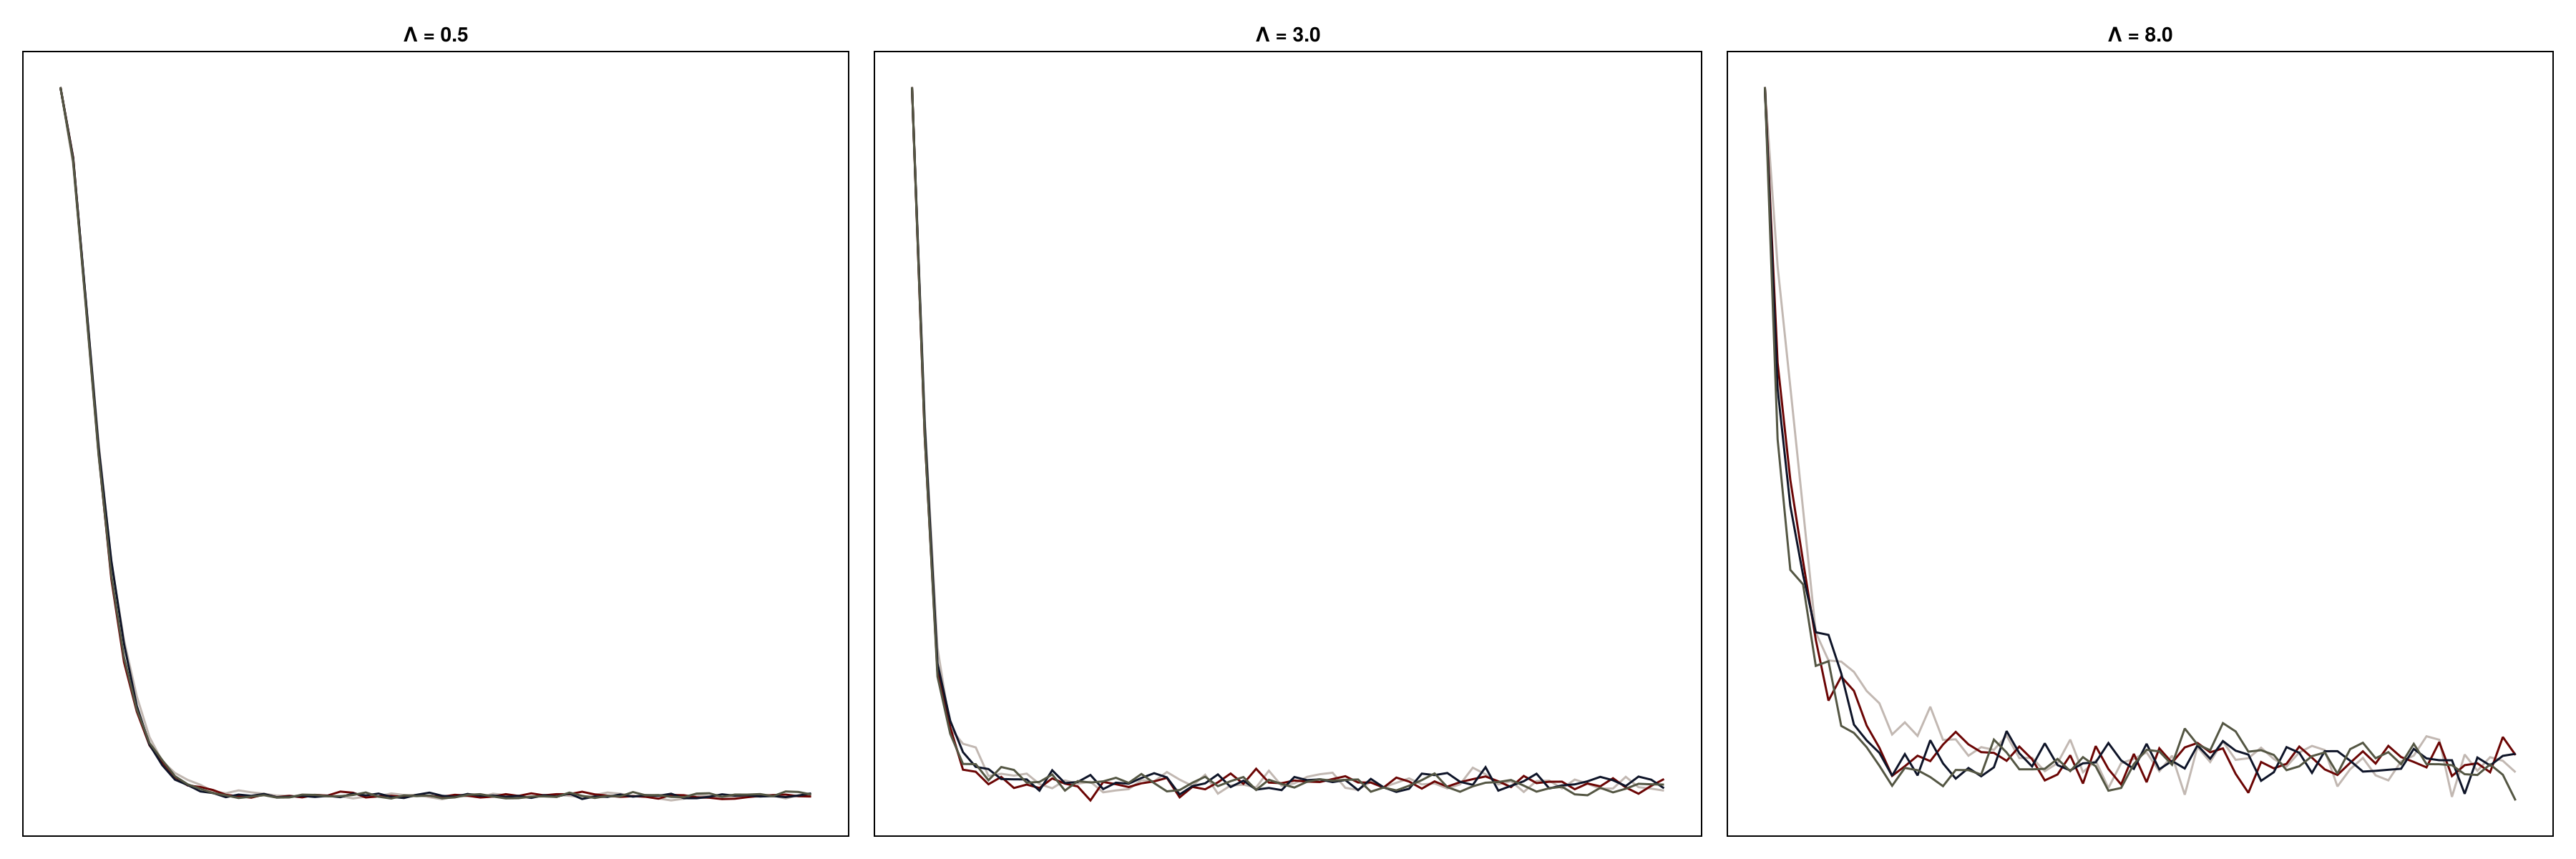

CairoMakie.Screen{IMAGE}


In [10]:
using CairoMakie
lambdas = [0.5, 3.0, 8.0]
steps = 60000

velocities = [5.0, 10.0, 20.0, 100.0]

dark = colorant"#0E1428"
red = colorant"#6B0504"
beige = colorant"#C2B8B2"
green = colorant"#545643"

colors = [beige, red, dark, green]

fig2 = Figure(size=(1800, 600))


for (idx, lambda) in enumerate(lambdas)

    
    # Create axis for this subplot
    ax_x = Axis(fig2[1, idx], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")
    

    hidedecorations!(ax_x)

    for (v_idx, v) in enumerate(velocities)

        df = dfs_redo[(v, lambda)]

        color = colors[v_idx]

        mean_x = Float64[]
        mean_y = Float64[]

        mask = (dc_delta.v .== v) .& (dc_delta.lambda .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        for i in 1:100:length(grouped)
            data_1 = grouped[i]
            x = data_1.x ./l
            y = data_1.y ./l

            push!(mean_x, mean(x))
            push!(mean_y, mean(x))
        end

        lines!(ax_x, (1:100:length(grouped))*0.1, mean_x, color = color, label = "$v")

        if idx == 3 & v_idx == 4
            fig2[1,4] = Legend(fig2, ax_x, "Bacteria speed")
        end
    end
end

display(fig2)

In [12]:
save("Plots/Fixed_source_model/Next/v_collapse_3_2.pdf", fig2)

CairoMakie.Screen{PDF}


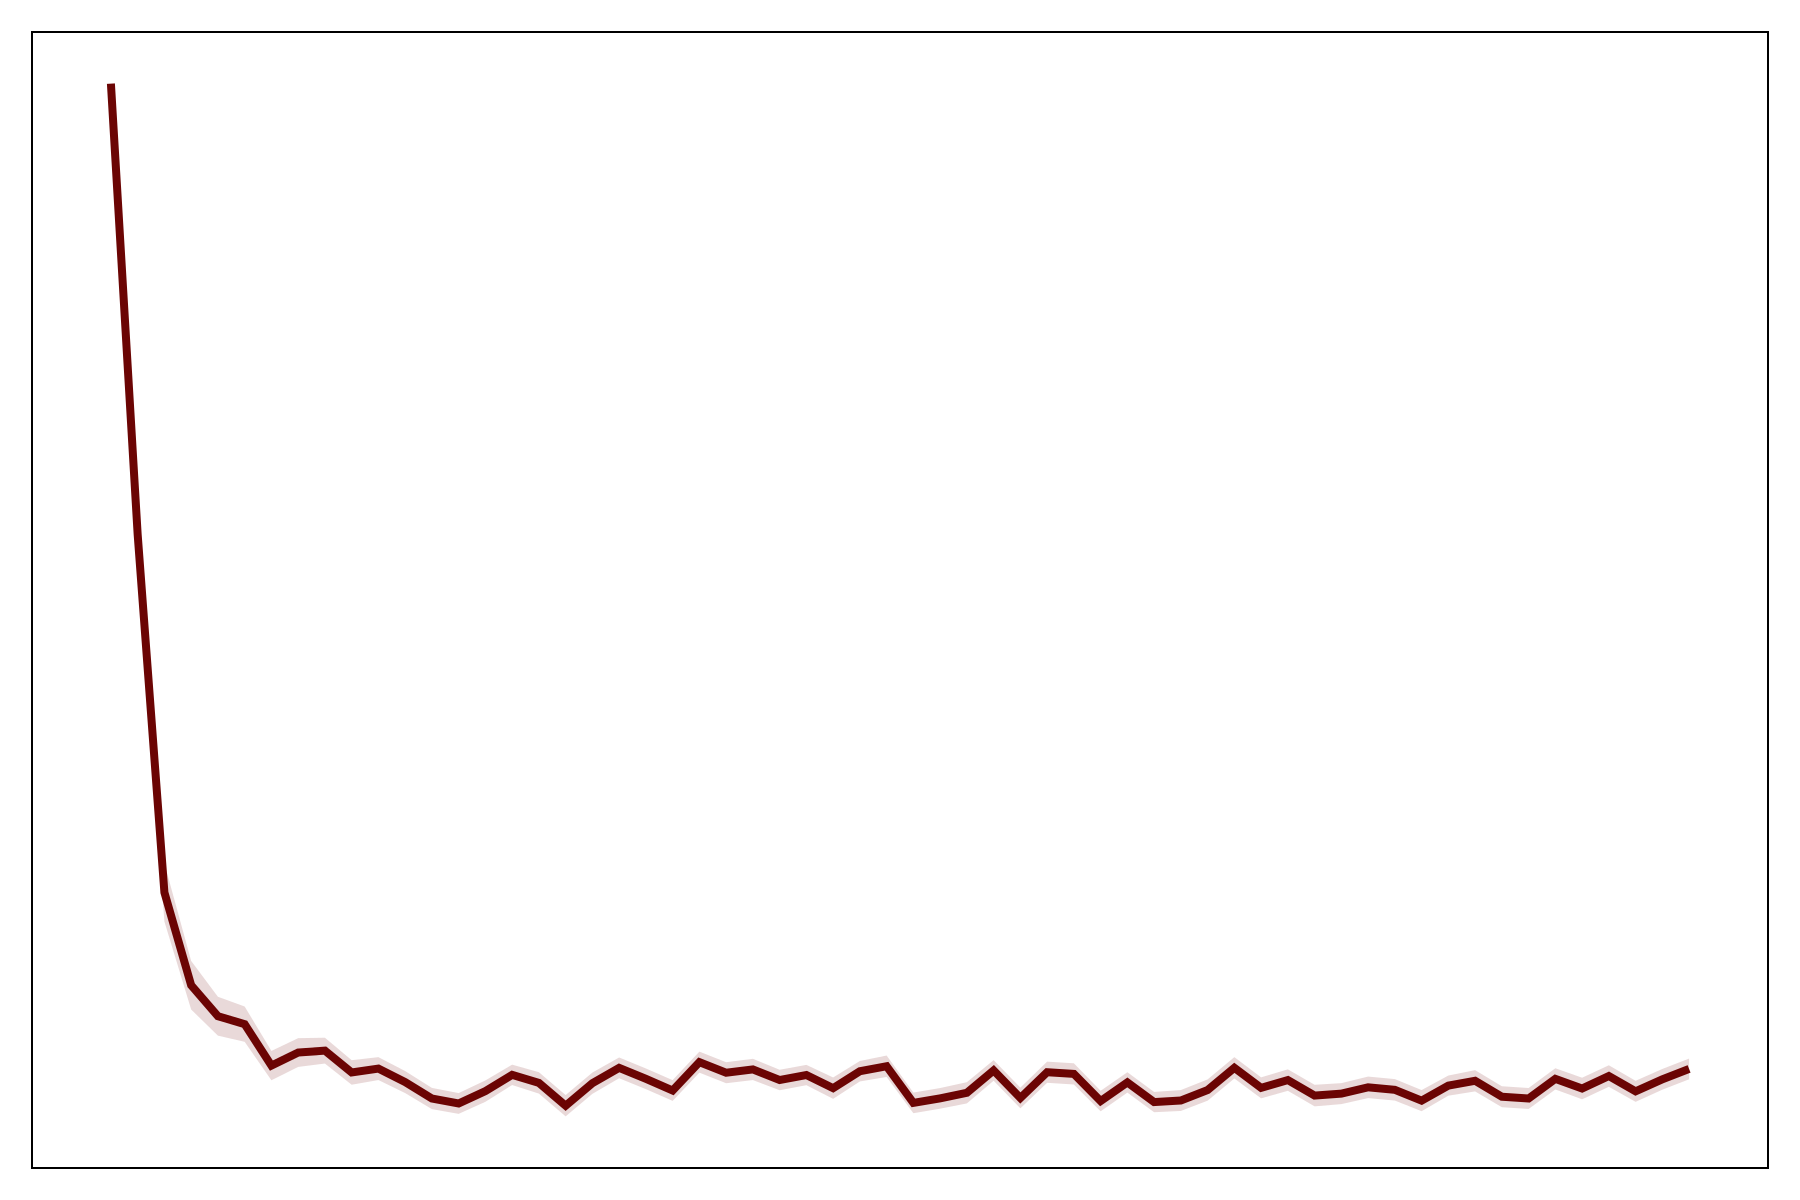

CairoMakie.Screen{IMAGE}


In [19]:
using CairoMakie
# lambdas = [0.5]
lambdas = [4.0]
steps = 60000

velocities = [10.0]
# velocities = [5.0]

g1 = colorant"#6B0504"
g2 = colorant"#904443"
g3 = colorant"#B58282"
g4 = colorant"#DAC0C0"
grad1 = colorant"#545643"
grad2 = colorant"#7F8072"
grad3 = colorant"#AAAAA1"
grad4 = colorant"#D4D5D0"

colors = [g1, g2, g3, g4]
color2 = [grad1, grad2, grad3, grad4]

fig2 = Figure(size=(900, 600))


for (idx, lambda) in enumerate(lambdas)

    
    # Create axis for this subplot
    ax_x = Axis(fig2[1, idx], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source")
    

    hidedecorations!(ax_x)

    for (v_idx, v) in enumerate(velocities)
        mean_dist_x = Float64[] 
        std_dist_x = Float64[]
        mean_dist_y = Float64[] 
        std_dist_y = Float64[]
        q_low_2 = Float64[]
        q_high_2 = Float64[]  
        df = dfs_redo[(v, lambda)]

        color = colors[v_idx]

        mean_x = Float64[]
        std_x = Float64[]
        mean_y = Float64[]
        std_y = Float64[]
        q_low = Float64[]
        q_high = Float64[]  

        N = Float64[]
        sem_x = Float64[]

        N2 = Float64[]
        sem_x2 = Float64[]

        mask = (dc_delta.v .== v) .& (dc_delta.lambda .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        for i in 1:100:length(grouped)
            data_1 = grouped[i]
            x = data_1.x ./l
            y = data_1.y ./l

            push!(mean_x, mean(x))
            push!(std_x, std(x))
            push!(mean_y, mean(y))
            push!(std_y, std(y))
            # push!(q_low, quantile(x, 0.25))
            # push!(q_high, quantile(x, 0.75))
            push!(N, length(x))

            push!(sem_x, std(x) / sqrt(length(x)))
        end

        lines!(ax_x, (1:100:length(grouped))*0.1, mean_x, color = colors[v_idx], label = "$v", linewidth = 4)
        # band!(ax_x, (1:100:length(grouped))*0.1, mean_x .+ std_x, mean_x .- std_x, color = (colors[v_idx], 0.1))
        # band!(
        #     ax_x,
        #     (1:100:length(grouped)) * 0.1,
        #     q_high,
        #     q_low,
        #     color = (colors[v_idx], 0.15)
        # )
        band!(
            ax_x,
            (1:100:length(grouped)) * 0.1,
            mean_x .+ sem_x,
            mean_x .- sem_x,
            color = (colors[v_idx], 0.15)
        )

        # jldopen("fsb_simulations/fsb_lambda_v$(v)_l$(lambda).jld2", "r") do file 

        #     for step in 1:steps
        #         g = file[@sprintf("step_%06d", step)]
                
        #         other_x = g["x"][1:1000]

        #         other_y = g["y"][1:1000]

        #         norm_x = other_x ./l
        #         norm_y = other_y ./l

        #         push!(mean_dist_x, mean(norm_x))
        #         push!(std_dist_x, std(norm_x))
        #         push!(mean_dist_y, mean(norm_y))
        #         push!(std_dist_y, std(norm_y))
        #         # push!(q_low_2, quantile(norm_x, 0.75))
        #         # push!(q_high_2, quantile(norm_x, 1))

        #         push!(N2, length(norm_x))

        #         push!(sem_x2, std(norm_x) / sqrt(length(norm_x)))
        #     end

        #     lines!(ax_x, (0.01:0.01:600), mean_dist_x, color = color2[v_idx])
        #     # band!(ax_x, (0.01:0.01:600), mean_dist_x .+ std_dist_x, mean_dist_x .- std_dist_x, color = (color2[v_idx], 0.1))
        #     # band!(ax_x, (0.01:0.01:600), q_low_2,q_high_2, color = (color2[v_idx], 0.1))
        #     band!(ax_x,
        #             (0.01:0.01:600),
        #             mean_dist_x .+ sem_x2,
        #             mean_dist_x .- sem_x2,
        #             color = (colors[v_idx], 0.15)
        #         )

        #     xlims!(ax_x, -10, 200)

        # end

    end
end

display(fig2)

In [20]:
save("Plots/Fixed_source_model/Next/ex_OU_l4_sem.pdf", fig2)

CairoMakie.Screen{PDF}


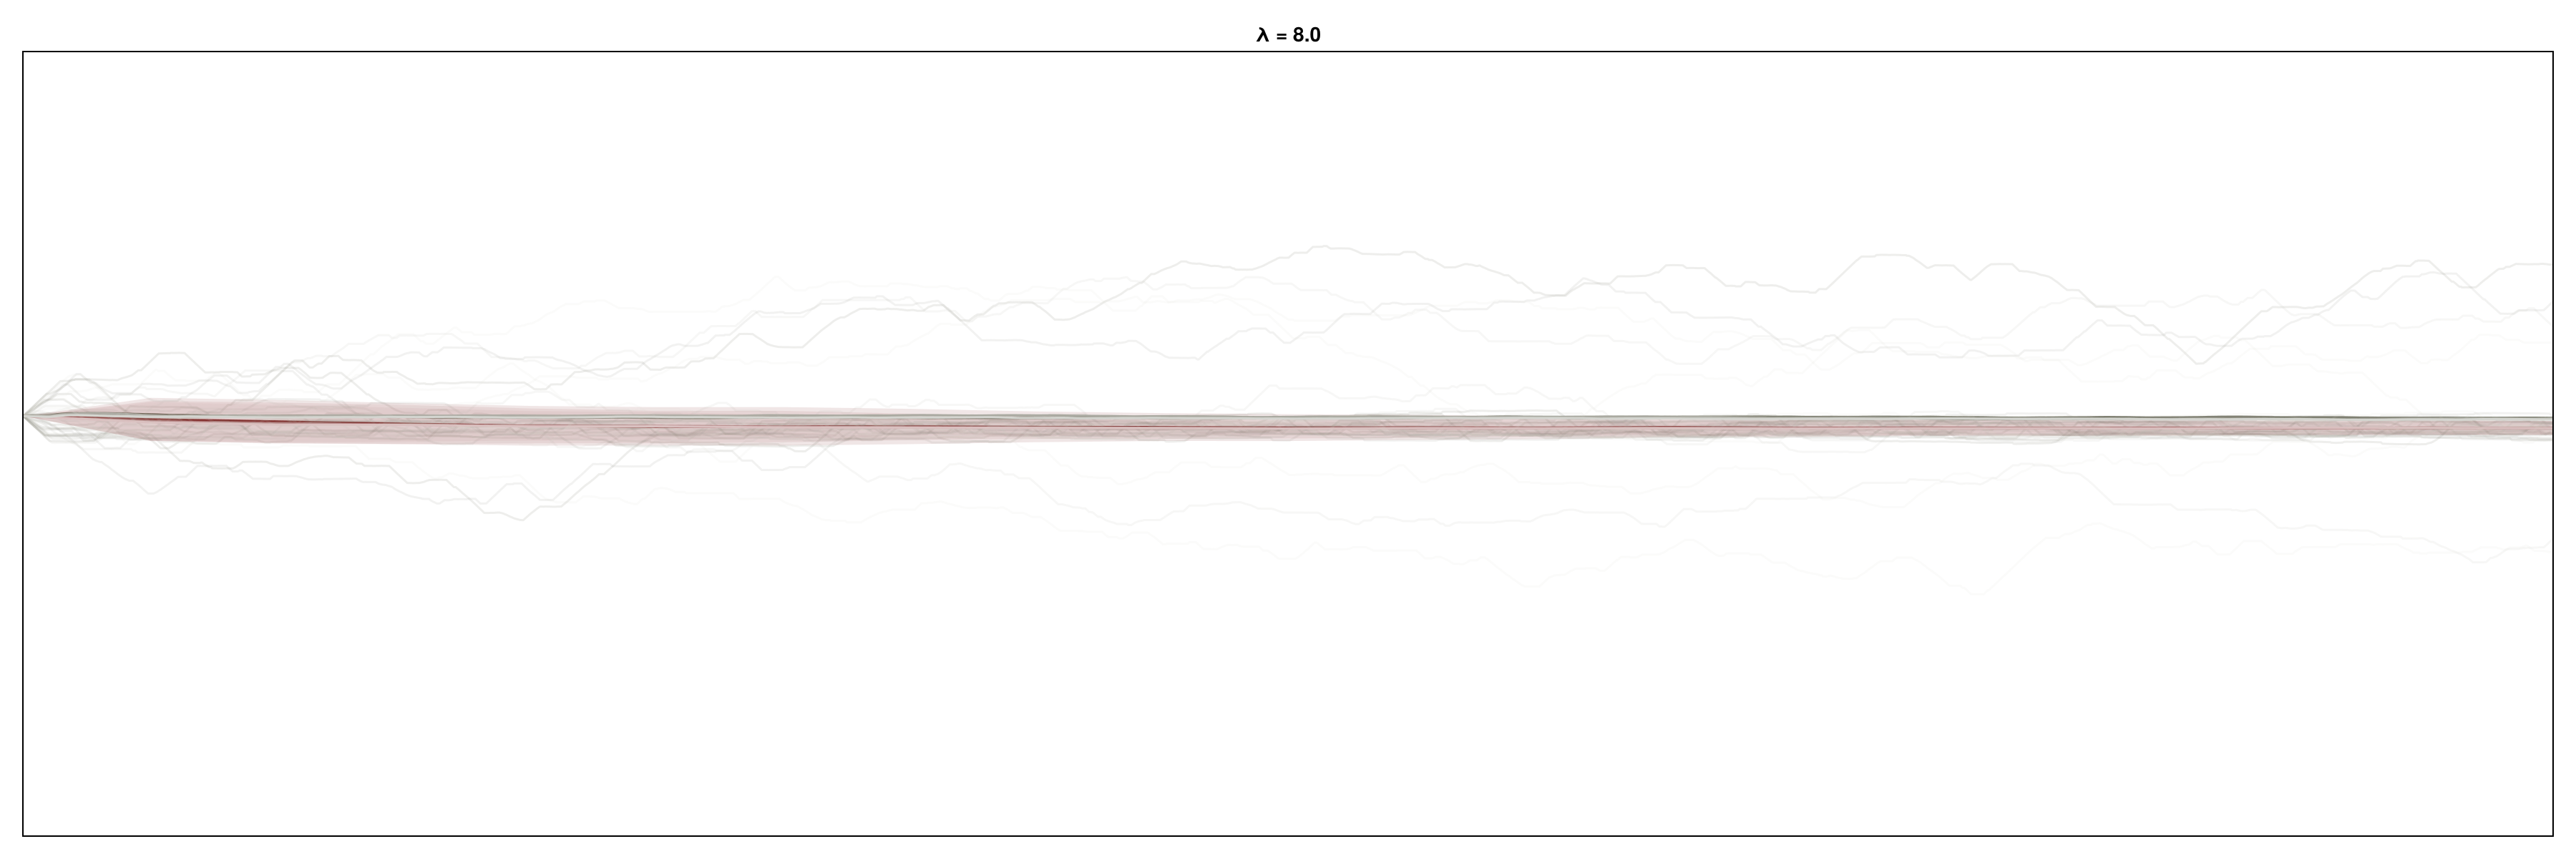

CairoMakie.Screen{IMAGE}


In [ ]:
using CairoMakie
using Random

lambdas = [8.0]
# lambdas = [0.5, 4.0, 8.0]
steps = 60000

velocities = [5.0, 10.0, 20.0, 100.0]

g1 = colorant"#6B0504"
g2 = colorant"#904443"
g3 = colorant"#B58282"
g4 = colorant"#DAC0C0"

grad1 = colorant"#545643"
grad2 = colorant"#7F8072"
grad3 = colorant"#AAAAA1"
grad4 = colorant"#D4D5D0"

colors = [g1, g2, g3, g4]
color2 = [grad1, grad2, grad3, grad4]

fig2 = Figure(size=(1800, 600))

Random.seed!(1234)

for (idx, lambda) in enumerate(lambdas)

    ax_x = Axis(
        fig2[1, idx],
        xlabel = "Time (s)",
        ylabel = "Relative Distance to Source",
        title = "λ = $lambda"
    )

    hidedecorations!(ax_x)

    for (v_idx, v) in enumerate(velocities)

        mean_dist_x = Float64[] 
        std_dist_x = Float64[]
        mean_dist_y = Float64[] 
        std_dist_y = Float64[]
        q_low_2 = Float64[]
        q_high_2 = Float64[]  

        df = dfs_redo[(v, lambda)]

        color = colors[v_idx]

        mean_x = Float64[]
        std_x = Float64[]
        mean_y = Float64[]
        std_y = Float64[]
        q_low = Float64[]
        q_high = Float64[]  

        N = Float64[]
        sem_x = Float64[]

        N2 = Float64[]
        sem_x2 = Float64[]

        mask = (dc_delta.v .== v) .& (dc_delta.lambda .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        for i in 1:100:length(grouped)
            data_1 = grouped[i]
            x = data_1.x ./l
            y = data_1.y ./l

            push!(mean_x, mean(x))
            push!(std_x, std(x))
            push!(mean_y, mean(y))
            push!(std_y, std(y))
            

        end

        lines!(ax_x, (1:100:length(grouped))*0.1, mean_x, color = colors[v_idx], label = "$v")
        band!(ax_x, (1:100:length(grouped))*0.1, mean_x .+ std_x, mean_x .- std_x, color = (colors[v_idx], 0.1))


        # =========================
        # SECOND DATASET
        # =========================

        mean_dist_x = Float64[]

        jldopen("fsb_simulations/fsb_lambda_v$(v)_l$(lambda).jld2", "r") do file
            for agent in 1:10
                individual_traj = []
                for step in 1:steps

                    g = file[@sprintf("step_%06d", step)]

                    other_x = g["x"][agent]

                    x = other_x / l
                    push!(individual_traj, x)
                end
                lines!(ax_x, (0.01:0.01:600), individual_traj, color = (color2[v_idx], 0.1))
            end

            for step in 1:steps

                g = file[@sprintf("step_%06d", step)]

                other_x = g["x"][1:1000]

                norm_x = other_x ./ l

                push!(mean_dist_x, mean(norm_x))

            end

            lines!(
                ax_x,
                (0.01:0.01:600),
                mean_dist_x,
                color = color2[v_idx]
            )

        end

        xlims!(ax_x, 0, 200)

    end

    # axislegend(ax_x, position = :rb)

end

display(fig2)

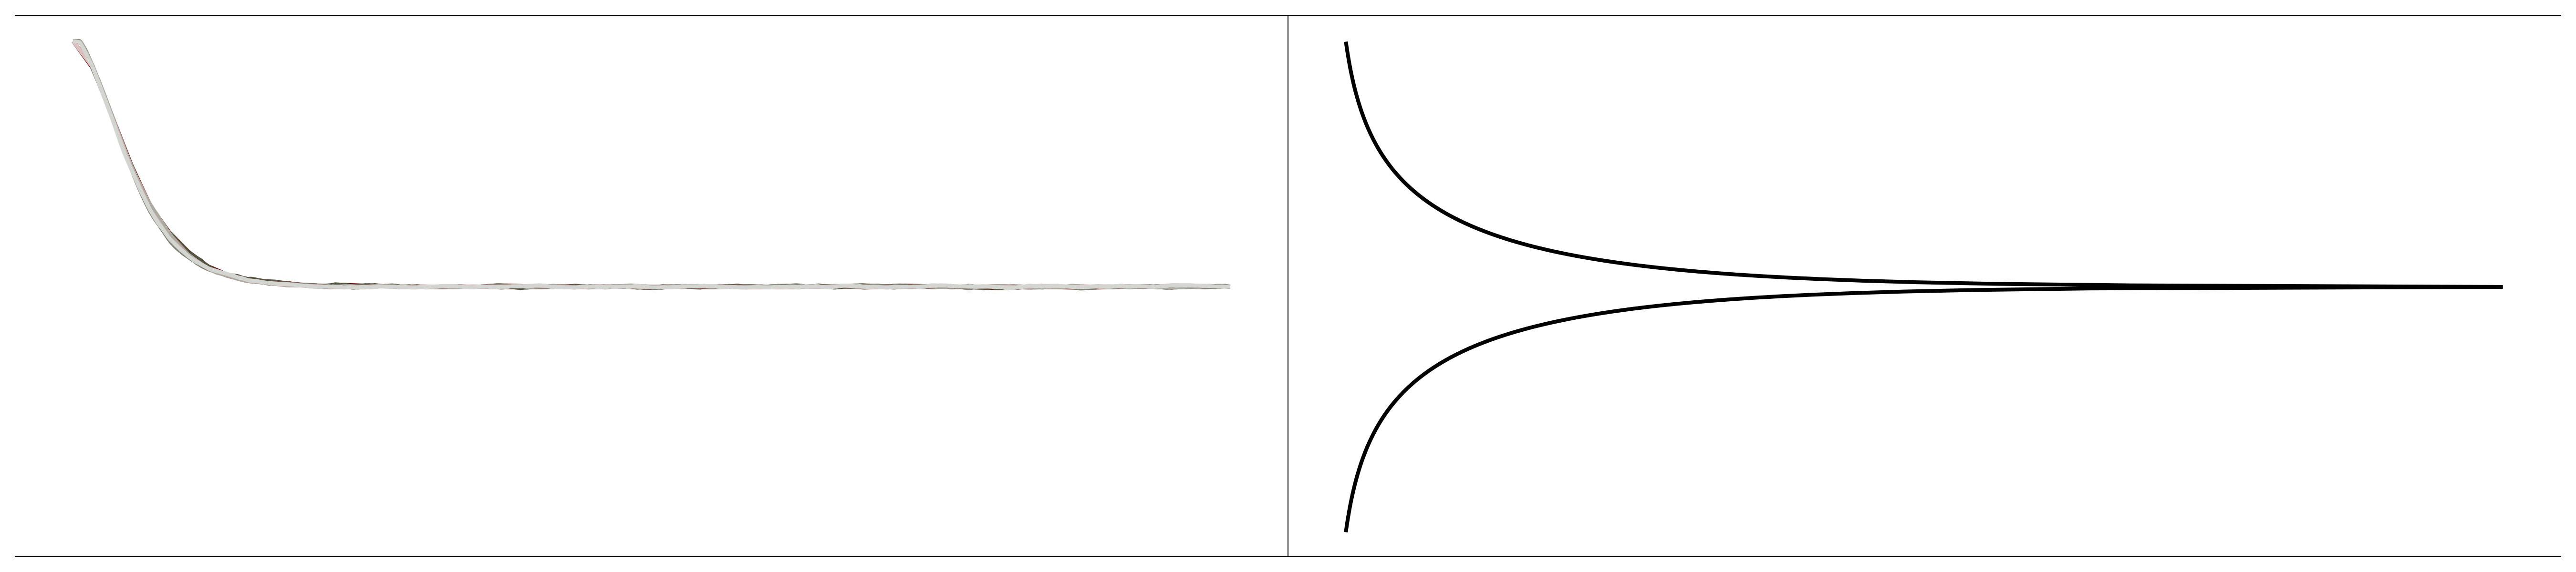

CairoMakie.Screen{IMAGE}


In [45]:
using CairoMakie
using SpecialFunctions

# ============================================================
# CONFIG
# ============================================================

lambdas = [0.5]
steps = 60000

velocities = [5.0, 10.0, 20.0, 100.0]

g1 = colorant"#6B0504"
g2 = colorant"#904443"
g3 = colorant"#B58282"
g4 = colorant"#DAC0C0"

grad1 = colorant"#545643"
grad2 = colorant"#7F8072"
grad3 = colorant"#AAAAA1"
grad4 = colorant"#D4D5D0"

colors = [g1, g2, g3, g4]
color2 = [grad1, grad2, grad3, grad4]

# ============================================================
# FIGURE
# ============================================================

fig = Figure(size = (2700, 600))

# ============================================================
# LEFT PANEL
# time vs distance
# ============================================================

    ax_left = Axis(
        fig[1, 1],
        xlabel = "Time (s)",
        ylabel = "Distance",
        yaxisposition = :right
    )

    # Flip horizontally so it opens away from center
    # reverse!(ax_left.xaxis)

    # ============================================================
    # RIGHT PANEL
    # field vs distance
    # ============================================================

    ax_right = Axis(
        fig[1, 2],
        xlabel = "Field Strength",
        ylabel = "",
        yticklabelsvisible = false
    )
    hidedecorations!(ax_left)
    hidedecorations!(ax_right)

    # ============================================================
    # LEFT PANEL DATA
    # ============================================================

for (idx, lambda) in enumerate(lambdas)

        for (v_idx, v) in enumerate(velocities)

            df = dfs_redo[(v, lambda)]

            color = colors[v_idx]

            mask = (dc_delta.v .== v) .& (dc_delta.lambda .== lambda)

            Dc_vals = dc_delta.Dc[mask]
            delta_vals = dc_delta.delta[mask]

            l = sqrt(mean(Dc_vals) / mean(delta_vals))

            grouped = groupby(df, :step)

            mean_x = Float64[]
            
            N = Float64[]
            sem_x = Float64[]

            # ====================================================
            # COMPUTE MEAN TRAJECTORY
            # ====================================================

            for i in 1:100:length(grouped)

                data_1 = grouped[i]

                xvals = data_1.x ./ l

                push!(mean_x, mean(xvals))
            
                push!(N, length(xvals))
                push!(sem_x, std(xvals) / sqrt(length(xvals)))

            end

            time_axis = (1:100:length(grouped)) .* 0.1

            lines!(
                ax_left,
                time_axis,
                mean_x,
                color = colors[v_idx],
                linewidth = 4,
                label = "v = $v, λ = $lambda"
            )
            band!(
                ax_left,
                time_axis,
                mean_x .+ sem_x,
                mean_x .- sem_x,
                color = (colors[v_idx], 0.15)
            )


            # ====================================================
            # SECOND DATASET
            # ====================================================

            mean_dist_x = Float64[]
            N2 = Float64[]
            sem_x2 = Float64[]

            jldopen("fsb_simulations/fsb_lambda_v$(v)_l$(lambda).jld2", "r") do file

                for step in 1:steps

                    g = file[@sprintf("step_%06d", step)]

                    other_x = g["x"][1:1000]

                    norm_x = other_x ./ l

                    push!(mean_dist_x, mean(norm_x))
                    push!(N2, length(norm_x))
                    push!(sem_x2, std(norm_x) / sqrt(length(norm_x)))

                end

                lines!(
                    ax_left,
                    (0.01:0.01:600),
                    mean_dist_x,
                    color = color2[v_idx],
                    linewidth = 4
                )
                band!(
                    ax_left,
                    (0.01:0.01:600),
                    mean_dist_x .+ sem_x2,
                    mean_dist_x .- sem_x2,
                    color = (color2[v_idx], 0.15)
                )


            end

        end
    end

    # ============================================================
    # RIGHT PANEL FIELD PROFILE
    # ============================================================

    mm_factor = 1.0
    Dc = 20
    delta = 0.005

    ll = sqrt(Dc / delta)

    r_max = 2.5 * ll

    distance = -r_max:1:r_max

    m_vals = mm_factor .* besselk.(0, abs.(distance) ./ ll)

    # IMPORTANT:
    # x = field
    # y = distance

    lines!(
        ax_right,
        m_vals,
        distance ./ ll,
        color = :black,
        linewidth = 4,
        label = "Bessel field"
    )

    # ============================================================
    # ALIGN DISTANCE AXES
    # ============================================================

    linkyaxes!(ax_left, ax_right)
    
    # Make panels touch
    colgap!(fig.layout, 0)

    # Clean center appearance
    ax_left.leftspinevisible = false
    ax_right.rightspinevisible = false



# ============================================================
# LIMITS / LEGENDS
# ============================================================

# ylims!(ax_left, -3, 3)

# axislegend(ax_left, position = :lb)
# axislegend(ax_right, position = :rt)

display(fig)

In [46]:
save("Plots/Fixed_source_model/Next/lambda_traj_field_05.pdf", fig)

CairoMakie.Screen{PDF}


In [21]:
@load "second_redo.jld2" sorted_metrics

1-element Vector{Symbol}:
 :sorted_metrics

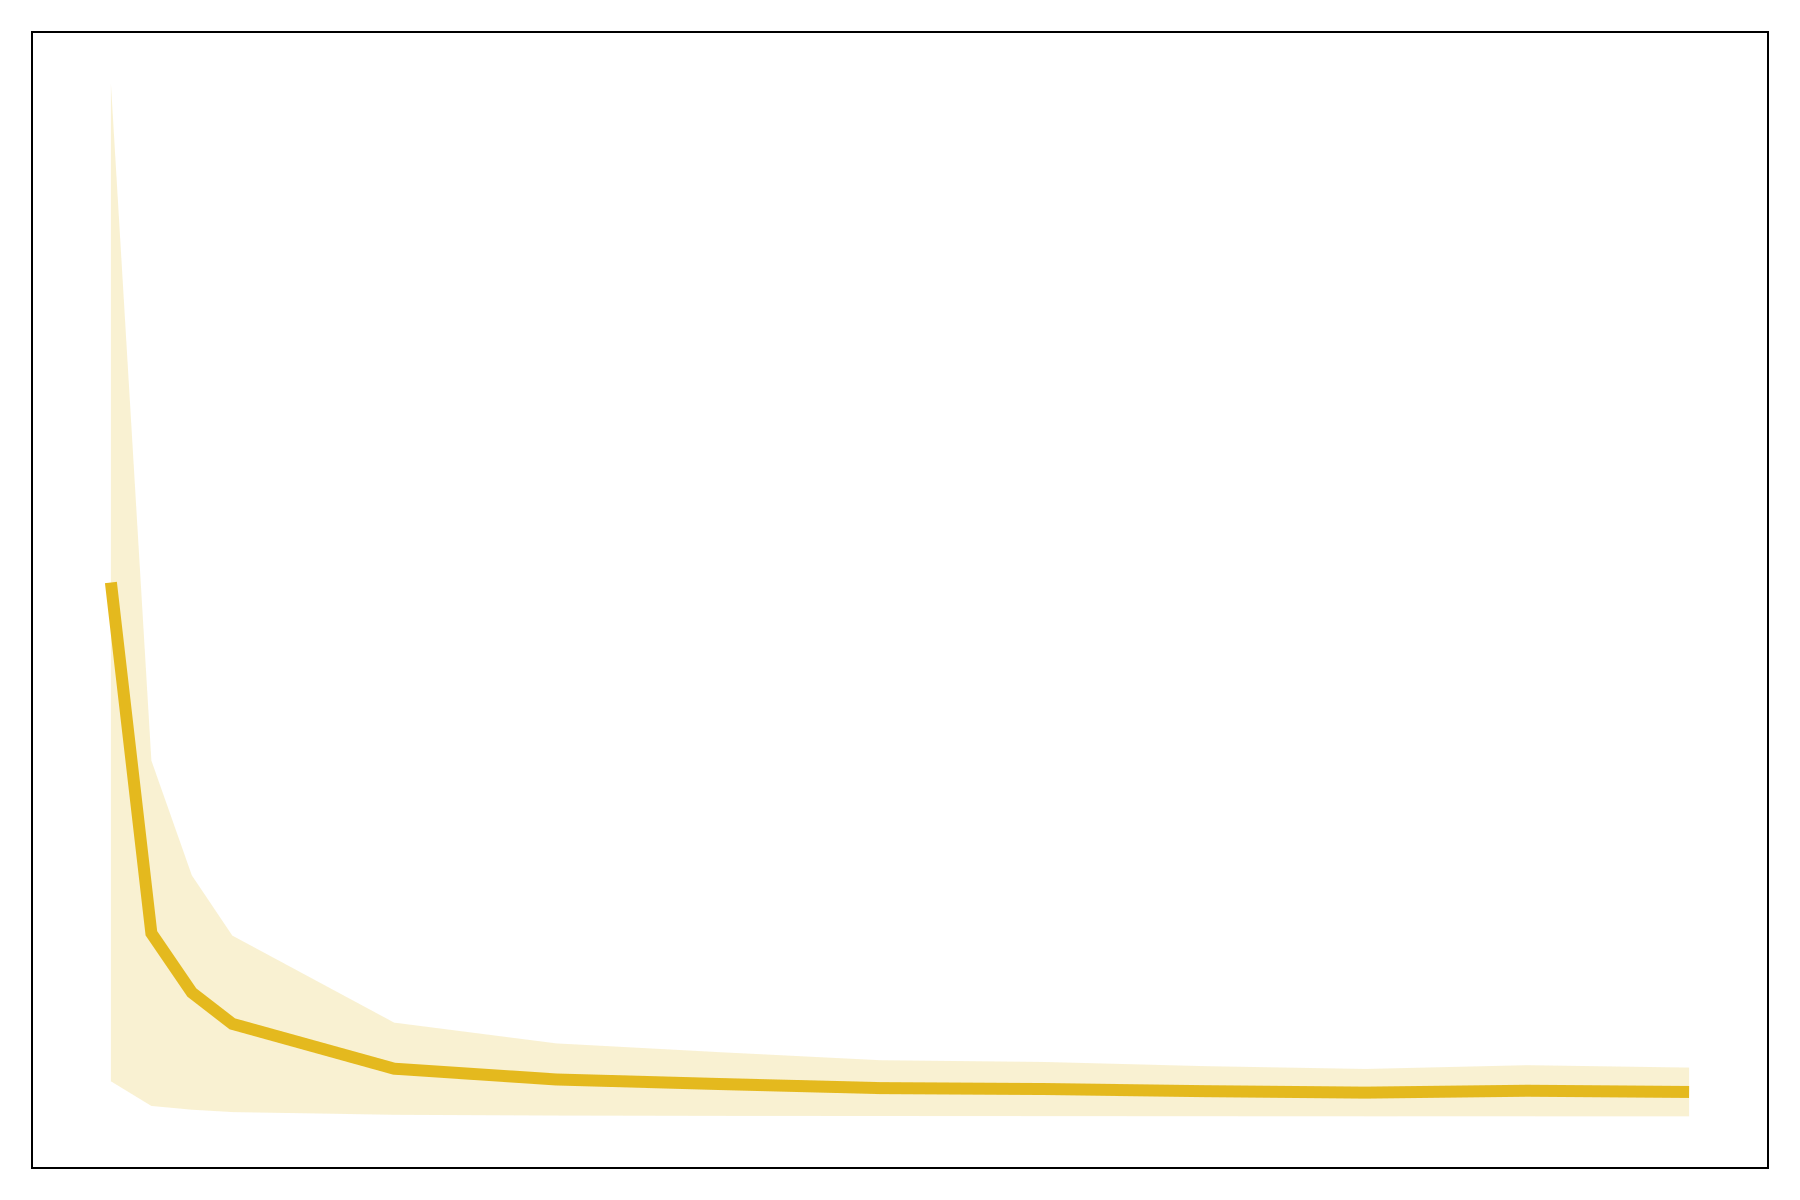

In [53]:
fig22 = Figure(size=(900, 600))
ax = Axis(fig22[1,1])
hidedecorations!(ax)
dark = colorant"#E5B91E"
lambda = sorted_metrics.lambda
k     = sorted_metrics.D_v

lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
mean_val = []
std_val = []
vel = [5.0, 10.0, 20.0, 100.0]
for (i, l) in enumerate(lambdas)

    this_lam = sorted_metrics[sorted_metrics.lambda .== l, :]
    # lines!(ax, this_lam.lambda, this_lam.D_v)
    push!(mean_val, mean(this_lam.D_v))
    push!(std_val, std(this_lam.D_v))
end

lines!(ax, lambdas, mean_val, color = dark, linewidth = 6)
band!(ax, lambdas, mean_val .+ (std_val/sqrt(4)), mean_val .- (std_val/sqrt(4)) , color = (dark, 0.2))
fig22


In [54]:
save("Plots/Fixed_source_model/Next/mean_D_std_yell_6.pdf", fig22)


CairoMakie.Screen{PDF}


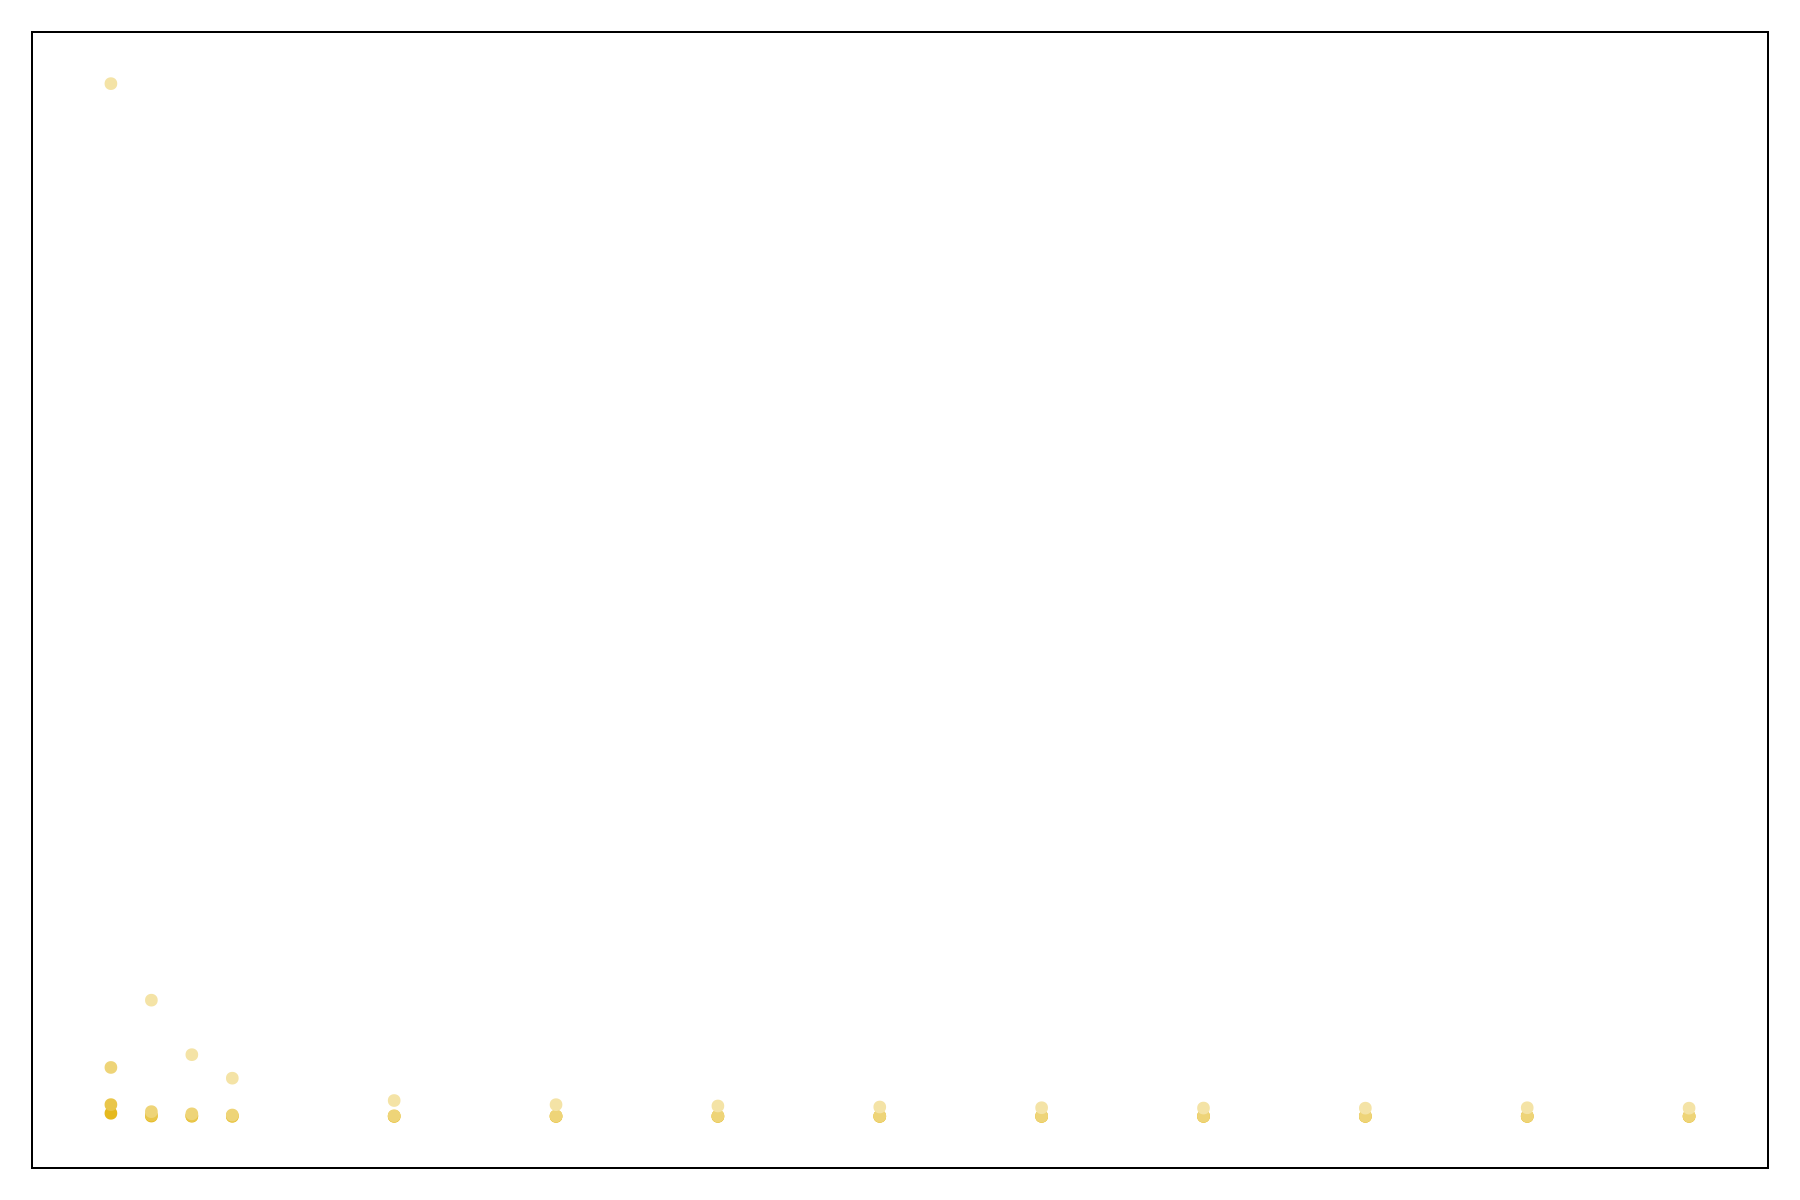

In [43]:
lambda = sorted_metrics.lambda
sigma = sorted_metrics.sigma
variance = sorted_metrics.variance
D = sorted_metrics.D_v
k     = sorted_metrics.k 
vvals = sorted_metrics.v

fig = Figure(size = (900, 600))
dark1 = colorant"#E5B91E"
dark2 = colorant"#E9C64B"
dark3 = colorant"#EED478"
dark4 = colorant"#F4E3A6"

colors = [dark1, dark2, dark3, dark4]
ax1 = Axis(fig[1, 1]
)
hidedecorations!(ax1)
# ax2 = Axis(fig[1, 2],
#     xlabel = "lambda",
#     ylabel = "k",
#     title = "lambda vs k"
# )

# ax3 = Axis(fig[1, 3],
#     xlabel = "k",
#     ylabel = "sigma",
#     title = "k vs sigma"
# )

# ax4 = Axis(fig[2,1],
#     xlabel = "lambda",
#     ylabel = "D",
#     title = "lambda vs D"
# )

# ax5 = Axis(fig[2,2],
#     xlabel = "Lambda",
#     ylabel = "Variance",
#     title = "Variance vs lambda"
# )

# ax6 = Axis(fig[2,3],
#     xlabel = "D",
#     ylabel = "k",
#     title = "k vs D"
# )
# unique velocities
unique_v = [5.0, 10.0, 20.0, 100.0]
mean_k = zeros(4, 13)

# choose a color palette


for (i, v) in enumerate(unique_v)

    idx = findall(==(v), vvals)
    
    mean_k[i, :] = k[idx]
    scatter!(ax1, lambda[idx], variance[idx],
        color = colors[i],
        label = "v = $v"
    )

end



fig

In [44]:
save("Plots/Fixed_source_model/Next/mean_D_std_yell_4.pdf", fig22)

CairoMakie.Screen{PDF}


In [40]:
df = dfs_redo[(10.0, 8.0)]
grouped = groupby(df, :agent)
length(grouped)

805

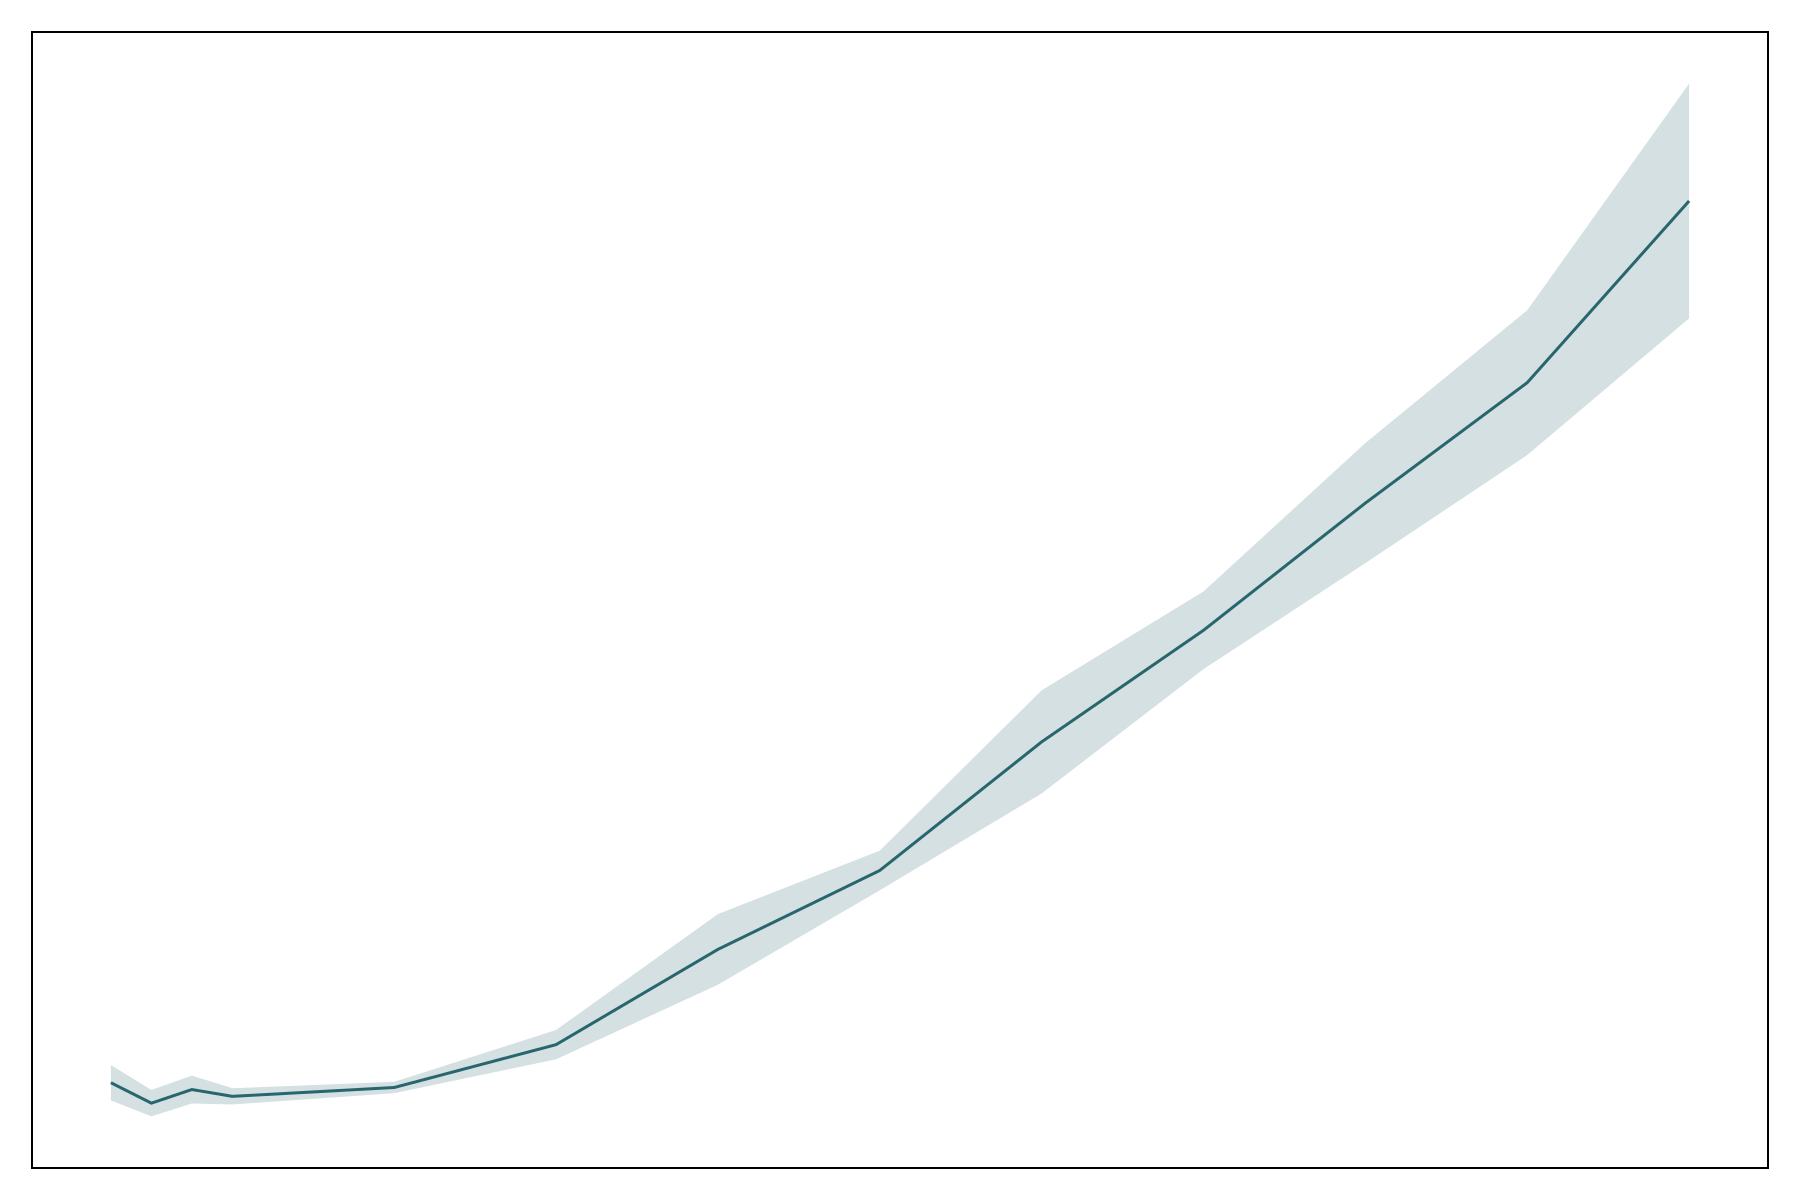

In [43]:
fig4 = Figure(size=(900,600))
ax = Axis(fig4[1,1])
hidedecorations!(ax)

color = colorant"#28666E"
escape = Float64[]
escape_std = Float64[]
velocities = [5.0, 10.0, 20.0, 100.0]

lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
for (idx, l) in enumerate(lambdas)
    Ps = []
    for (idx_v, v) in enumerate(velocities)
        df = dfs_redo[(v, l)]
        grouped = groupby(df, :agent)
        agents = length(grouped)
        P = 1 .- (agents/1000) 
        push!(Ps, P)
    end
    push!(escape, mean(Ps))
    push!(escape_std, std(Ps))
 
end
lines!(ax, lambdas, escape, color = color)
band!(ax, lambdas, escape .+ escape_std, escape .- escape_std, color = (color, 0.2))
fig4

In [44]:
save("Plots/Fixed_source_model/Next/escape_prob_mean.pdf", fig4)

CairoMakie.Screen{PDF}
